Tareq El Kajjyouy

> Nature uses only the longest threads to weave her patterns, so that each small piece of her fabric reveals the organization of the entire tapestry.
- Richard P. Feynman

# **SCHRÖDINGER'S EQUATION**
## Reason for which I chose this project work
I decided to analyze the *Schrödinger Equation*. Given my deep passion for classical, lagrangian and analytical mechanics, applying my "Model Order Reduction" knowledge for such system was quite exciting.




## Model Order Reduction for the Schrödinger Equation
 In this brief work, my objective was to highlight, in each code, the reasoning behind certain choices and the lines of codes which helped me to develop certain conclusions. The assignment addresses the numerical simulation of an electron confined within a bi-crystal disk $\Omega$ performed  governed by the time-dependent Schrödinger equation. The objective was to construct a **Reduced Order Model** to efficiently approximate the wave function $\Psi$ and analyze the electron's probability distribution. The system was modeled by the Schrödinger equation, defined as:
$$i\hbar\frac{\partial\Psi}{\partial t}=-\frac{\hbar^{2}}{2m}\Delta\Psi+V_{\mu}\Psi$$

where the parametrized potential $V_{\mu}$ (with $\mu=[E, \Delta V_{0}]$) is given by:

$$V(x; \mu)=E^{\top}x+\Delta V_{0}1_{[0,+\infty)}(x_{2})$$


In [1]:
try:
     from dlroms import*
except:
     !pip install --no-deps git+https://github.com/NicolaRFranco/dlroms.git
     from dlroms import*
import numpy as np
import matplotlib.pyplot as plt
clc()

In [2]:
# # Downloading the dataset
# import gdown
# gdown.download(id = "1LSww0NSGn-6pd_fkQosU9Uw2qxz3dp3a", output = "datageneration.npz", quiet=False)


In [3]:
# CREATE THE GEOMETRY
domain = fe.circle((0, 0), 1.0/np.pi)                             # we define the domain. It is a circle of radius 1/pi as written on the text
mesh = fe.mesh(domain, stepsize = 0.02)                           # we define the mesh as always. This one has a very small stepsize
Vh = fe.space(mesh, 'CG', 1)                                      # Continuous Galerking is given by "CG" and degree of polynomial = 1
nh = Vh.dim()                                                     # with this, we define the dimension of Nh
clc()


## DEFINE THE FULL ORDER MODEL (FOM)
def FOMsolver(E, deltaV0, steps = 99, dt = 1e-3):                                          # with this, we define a complete model of FOM
  from fenics import inner, grad, dx, div, assemble, DirichletBC, Constant, Expression     # importing the libraries
  from scipy.sparse.linalg import spsolve                                                  # importing the libraries
  from scipy.sparse import bmat                                                            # importing the libraries


# DEFINE THE ASSUMPTIONS FOR OUR SYSTEM:
  potential = fe.interpolate(lambda x: E*(x[0]/np.sqrt(2.0) - x[1]/np.sqrt(2.0)) + deltaV0*(x[1] > 0), Vh)  # It creates an electric potential field/force distribution ( sarebbe V_miu(x) )
  # potential defines the E vector and defines that DELTA V_0>0
  S = fe.assemble(lambda u, v: inner(grad(u), grad(v))*dx, Vh)  # developing the STIFFNESS matrix
  M = fe.assemble(lambda u, v: u*v*dx, Vh)                      # developing the MASS matrix
  V = fe.assemble(lambda u, v: potential*u*v*dx, Vh)            # developing the POTENTIAL matrix


# DEFINE THE BCs
  bc = fe.DirichletBC(lambda x: True, 0.0)                      # defining the boundary condition
  B = S + V                                                     # sum of the two matrices
  B = fe.applyBCs(B, Vh, bc)                                    # dirichlet boundary conditon which insert ZERO dofs on boundary; we know that it is dirichlet since upper we have bc = fe.DirichletBC(lambda x: True, 0.0)
  M = fe.applyBCs(M, Vh, bc)                                    # dirichlet boundary conditon which insert ZERO dofs on boundary; we know that it is dirichlet since upper we have bc = fe.DirichletBC(lambda x: True, 0.0)
# We just set S, V, M as zero on the boundaries


# TO CONSIDER BOTH REAL AND IMAGINARY PARTS
  A = bmat([[M, -dt*B], [dt*B, M]])                             # Obtained through the Backward Euler (proved)
  M2 = bmat([[M, 0*M], [0*M, M]])                               # It has 0*M because we have M dimensions


# DEFINE THE INITIAL CONDITIONS AND MAKE IT AS A VECTOR
  u0_real = fe.interpolate(lambda x: np.exp(-100*(x[0]**2+x[1]**2)), Vh)   # real part of the initial condition
  u0_imag = fe.interpolate(0.0, Vh)                                        # imaginary part of the initial condition (i.e. it is completely null)
  u0_real_vec = fe.dofs(u0_real)                                           # we have the real part of the function of the initial condition as a vector
  u0_imag_vec = fe.dofs(u0_imag)                                           # we have the imaginary part of the function of the initial condition as a vector
  states = [np.concatenate((u0_real_vec, u0_imag_vec))]                    # we unify the real and imaginary part vectors of the function in one single vector


# DEVELOP THE MATRIX BY ADDING CONTINUOUSLY THE TIME INFORMATION
  for n in range(steps):                                                    # for each time interval
    now = states[-1]
    rhs = M2 @ now                                                          # consider the very last state (i.e. the present)
    rhs[:nh] = fe.applyBCs(rhs[:nh], Vh, bc)                                # for the new interval time, we calculate the mass matrix (update) and leave BC = 0; # spsolve allows to solve the linear system
    rhs[nh:] = fe.applyBCs(rhs[nh:], Vh, bc)
    next = spsolve(A, rhs)
    states.append(next)                                                     # append the new info
  clc()
  return np.stack(states)                                                   # it transforms the list in a matrix (rows = time ; FEM dofs)


## TASK 3 ; AUXILIARY FUNCTIONS
from fenics import dx
M = fe.assemble(lambda u, v: u*v*dx, Vh)                                              # Mass matrix in integral form
clc()

# Define the PDF (p_t)
def probabilities(u):
  unnormalized_probabilities = (u.reshape(-1, 2, nh)**2).sum(axis = 1)                # I separate the real and imag components for each temporal instant and then evaluate the magnitude (|psi| = psi_real^2 + psi_imag^2)
  integrals = (unnormalized_probabilities @ M).sum(axis = -1)                         # Here, I obtain the integral form of psi
  return unnormalized_probabilities/integrals.reshape(-1, 1)                          # Here, I obtain p_t present in slides (PDF).

# Define the complete function of probability (double integral)
def caught(prob):
  T = 0.1                                                          # Define the period (T = dt * steps)
  times = np.linspace(0, T, 100)                                   # Define the time axis
  indicator = fe.dofs(fe.interpolate(lambda x: x[1]>0, Vh))        # Define the domain from which we saw that, from the file pdf, x_2 > 0. This is simply C_top (piastra superiore). It is a vector belonging between 0 and 1.
  return (prob @ M @ indicator).mean()                             # It is the formula of P.  prob @ M @ indicator is the inner integral p_t(x) dx; mean is defining the outer integral and the T at the denominator (it is a continuous mean)

### **Data Generation**

As requested from the text, for the generation, a total of **30 FOM simulations** were generated, which then have been splitted in half. For each sample, the parameters

$$
E \in [0,1000], \qquad \Delta V_0 \in [0,1000]
$$

were randomly drawn from a uniform distribution.

The generated dataset consists of: $n_{\text{samples}}=30$ parameter matrix = $\mu \in \mathbb{R}^{30 \times 2}$, snapshot matrix = $u \in \mathbb{R}^{30 \times n_t \times 95}$, number of simulations = $30$, $n_t$ = $99$ and FOM dimension = $95$. In practice, the code solves the PDE 30 times, each simulation corresponding to a different randomly selected parameter pair ($E,\Delta V_0)$. The dataset was then split into **15 training simulations** and **15 testing simulations** for the subsequent POD analysis and ROM construction.

1. Data generation: I generate the data through a for cycle with "nsamples" iterations. As output, we obtain the matrices $\mu$ and $u$.
2. I generated $U_{train}$ starting from $u$, by simply considering the training values. After the truncation, I defined $u$ as a 2D matrix through a reshape because I need this form in order to apply the SVD.
3. Consequently, I applied the SVD and defined the $V$ matrix through the help of the spectrum of the singular values.

## Full order model

In [4]:
import os
import gdown
import numpy as np

FILENAME = 'Assignment1_Tareq.npz'
GOOGLE_DRIVE_LINK_OR_ID = 'https://drive.google.com/file/d/1bR9pulf_q6E_wNQ_dNhUHKF38KcKzOLG/view?usp=drive_link'

if 'drive.google.com/file/d/' in GOOGLE_DRIVE_LINK_OR_ID:
    GOOGLE_DRIVE_FILE_ID = GOOGLE_DRIVE_LINK_OR_ID.split('/d/')[1].split('/view')[0]
else:
    GOOGLE_DRIVE_FILE_ID = GOOGLE_DRIVE_LINK_OR_ID

if os.path.exists(FILENAME):
    print(f"Loading data from existing '{FILENAME}' file...")
    data_loaded = True
elif GOOGLE_DRIVE_FILE_ID and GOOGLE_DRIVE_FILE_ID != 'YOUR_GOOGLE_DRIVE_FILE_ID':
    print(f"Downloading '{FILENAME}' from Google Drive ID: {GOOGLE_DRIVE_FILE_ID}...")
    try:
        gdown.download(id=GOOGLE_DRIVE_FILE_ID, output=FILENAME, quiet=False)
        data_loaded = True
    except Exception as e:
        print(f"Error downloading file: {e}")
        data_loaded = False
else:
    print("No pre-saved data found or Google Drive ID provided. Proceeding with data generation.")
    data_loaded = False

if data_loaded:
    print(f"Loading data from '{FILENAME}'...")
    data = np.load(FILENAME)
    mu = data['mu']
    u = data['u']
    if 'Es_exceed' in data.files and 'P_exceed' in data.files and 'P_total' in data.files and 'Es_total' in data.files and 'P_results' in data.files:
        P_total = data['P_total']
        Es_total = data['Es_total']
        Es_exceed = data['Es_exceed']
        P_exceed = data['P_exceed']
        P_results = data['P_results']
    print("Data loaded successfully!")

Downloading...
From (original): https://drive.google.com/uc?id=1bR9pulf_q6E_wNQ_dNhUHKF38KcKzOLG
From (redirected): https://drive.google.com/uc?id=1bR9pulf_q6E_wNQ_dNhUHKF38KcKzOLG&confirm=t&uuid=76163ae2-b642-4849-ad7c-147292c58d28
To: /content/Assignment1_Tareq.npz
100%|██████████| 47.8M/47.8M [00:01<00:00, 30.6MB/s]


Loading data from 'Assignment1_Tareq.npz'...
Data loaded successfully!


## Data generation


In [5]:
if not data_loaded:
    print("Generating new data...")
    # Data generation
    # values of the parameters range from 0 to 1000
    # have 2 parameters: E and V0

    nsamples = 30                                                                   # number of samples
    muList = []                                                                    # list of parameters
    uList = []                                                                     # list of solutions evaluated (based on mu) with FOM model
    for i in range(nsamples):
      E = 1000*np.random.rand()                                                    # get random values in 0 - 1, multiply by 1000 to get them between 0 and 1000
      deltaV0 = 1000*np.random.rand()                                              # define get random values in 0 - 1, multiply by 1000 to get them between 0 and 1000
      mu_current = np.array([E, deltaV0])                                          # create the vector of parameters
      u_current = FOMsolver(mu_current[0], mu_current[1])                          # pass E and deltaV0 separately
      muList.append(mu_current)                                                    #adding values to list
      uList.append(u_current)                                                      #adding values to list

    mu = np.stack(muList)
    u = np.stack(uList)

    print(f"The number of trajectories is {u.shape} (u)")
    print(f"The number of parameters is {mu.shape} (mu)")
else:
    print("Skipping data generation as data was loaded from file.")
    # mu and u are already loaded
    nsamples = mu.shape[0] # Define nsamples from the loaded data

E = 1000*np.random.rand()                                                    # get random values in 0 - 1, multiply by 1000 to get them between 0 and 1000
deltaV0 = 1000*np.random.rand()                                              # define get random values in 0 - 1, multiply by 1000 to get them between 0 and 1000

Skipping data generation as data was loaded from file.


In [6]:
# nsamples = 30    # Given by the professor. It is associated to the FOM dimension number

# muList = []                              # Parameters list
# uList = []                               # Solution list
# for i in range(nsamples):
#     E = 1000* np.random.rand()           # (0, 1000)
#     deltaV0 = 1000 * np.random.rand()    # (0, 1000)
#     mu_current = np.array([E, deltaV0])  # I append the values of the parameters
#     u_current = FOMsolver(E, deltaV0)    # I put the solution associated to the value of the parameters obtained; it iterates multiple times the process.
#     muList.append(mu_current)
#     uList.append(u_current)
# mu = np.stack(muList)
# u = np.stack(uList)
# # by running this code, we are solving the PDE 30 times; each row is representing one solution of the PDE

# print(f"The dimension (Vh) is: {Vh.dim()}") # Vh.dim = 95
# print(f"The number of trajectories (u) is: {u.shape}, on which: 1st value = number of data (ndata), 2nd value = number of time instants (nt), 3rd value = number of degrees of freedom (nh).")
print(f'The dimension of the mu vector is: {mu.shape}')

The dimension of the mu vector is: (30, 2)


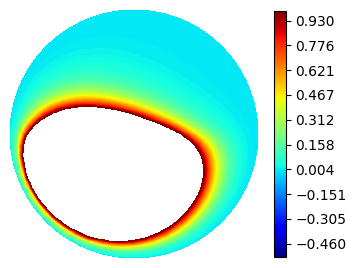

In [7]:
# Plot at a certain time instant, for a certain sample.
fe.multiplot(probabilities(u[1, -1, :]), (1, 1), Vh, colorbar = True, vmin = u.min(), vmax = u.max())

## Application of the SINGULAR VALUE DECOMPOSITION



In [8]:
from scipy.linalg import svd # this allows us to do the SINGULAR VALUE DECOMPOSITION
# nsamples represents the total number of high-fidelity simulations (snapshots) => each sample is a solution of the FOM
# ntrain represents the total number samples considered to develop the model

ntrain = nsamples//2                                                    # I consider the first 15 simulations.
ndata, nt, nh = u.shape                                                 # u.shape is a tensor which has ndata, nt and nh. If there was no time dependence, then we'd only have a matrix ndata x nh
Utrain = (u[:ntrain]).reshape(ntrain*nt, nh).T                          # Create the tensor of training by considering only the ":ntrain" samples (i.e. 15) and reshape in that specific form as written inside (...)
# I do the reshape in order to have a matrix
# we want a matrix with dimension nh x nsnapshots (nsnapshots = ntrain x numero_passi_temporali)
# Utrain is the SNAPSHOT MATRIX

# Calculating the svd
X, s, Yt = svd(Utrain, full_matrices = False) #
# s = vector of the singular values (it contains all the singular values)
# X => left eigenvector matrix
# Yt => right eigenvector matrix
Utrain.shape, X.shape, s.shape, Yt.shape

((1990, 1500), (1990, 1500), (1500,), (1500, 1500))

In [9]:
nt

100

In [10]:
print(f"The snapshot matrix is expected to have some zero rows. This is due to the fact:")
Utrain

The snapshot matrix is expected to have some zero rows. This is due to the fact:


array([[ 3.97807744e-05,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.17369294e-04, -4.65224853e-04, -1.37119214e-04, ...,
        -1.09751793e-05, -7.67669697e-05, -1.42340702e-04],
       [ 1.24760860e-04, -3.41585590e-04,  2.45480483e-04, ...,
        -7.26643935e-06, -5.09021490e-05, -9.43967625e-05],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [11]:
print(f"The dimension of u is {u.shape}, on which: 1st value = number of data (ndata), 2nd value = number of time instants (nt), 3rd value = number of degrees of freedom (nh).")
print(" ")
print(f"The dimension of Utrain is {Utrain.shape}, on which: 1st value = number of degrees of freedom (nh), 2nd value = number of snapshots (ntrain * nt).")
print(" ")
print(f"The number of singular values is {len(s)}.")
print(" ")
print(f"The dimension of X is {X.shape}, on which: 1st value = number of degrees of freedom (nh), 2nd value = number of snapshots (ntrain * nt).")

print("X = complete eigenvector matrix; s = complete singular values; Utrain = ")

The dimension of u is (30, 100, 1990), on which: 1st value = number of data (ndata), 2nd value = number of time instants (nt), 3rd value = number of degrees of freedom (nh).
 
The dimension of Utrain is (1990, 1500), on which: 1st value = number of degrees of freedom (nh), 2nd value = number of snapshots (ntrain * nt).
 
The number of singular values is 1500.
 
The dimension of X is (1990, 1500), on which: 1st value = number of degrees of freedom (nh), 2nd value = number of snapshots (ntrain * nt).
X = complete eigenvector matrix; s = complete singular values; Utrain = 


## Extraction of the POD basis and number of modes to consider

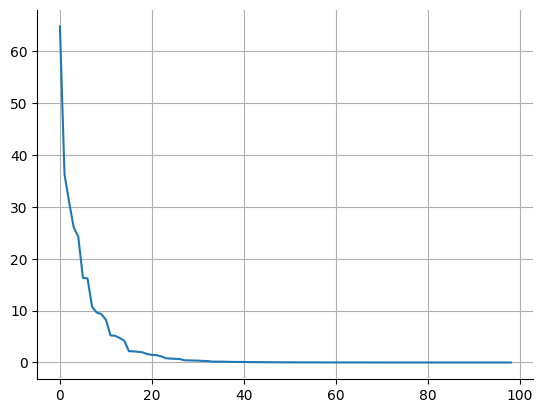

In [12]:
# Plot
plt.plot(s[1:100])  # Plot of the singular values
# I put 50 to zoom in and i put 1 due to PCA

# Custom the plot
plt.grid(True, which="both")
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

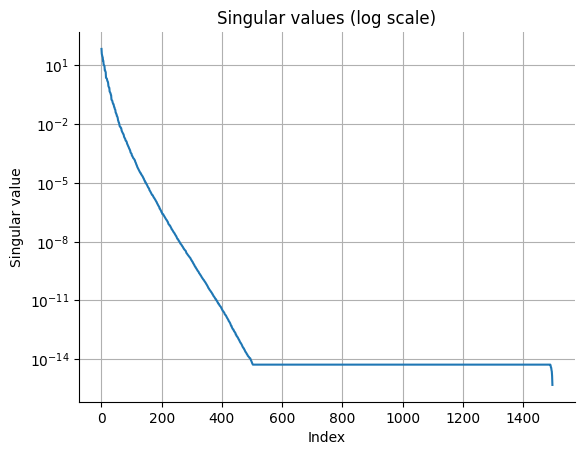

In [13]:
# Plot in log scale
plt.plot(s[1:])
plt.yscale('log')

# Custom the text
plt.xlabel('Index')
plt.ylabel('Singular value')
plt.title('Singular values (log scale)')

# Add grid and show
plt.grid(True, which="both")
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

# qui ho n approssimativamente uguale a 450 (devo trovare il plateau)

In [14]:
n = 30
# number of basis functions to be considered (I decided it from the graph's behavior; I considered an even number for purpose). The idea is to see the index for which  the curve starts being around zero.

In [15]:
u.shape

(30, 100, 1990)

In [16]:
Vn = X[:, :n]          # Truncate the left eigenvectors' matrix up to n
print(f"The shape of Vn is expected to be {Vn.shape}, which shows how the dimension is like {X.shape} in terms of columns, but in terms of rows we truncate many eigenvectors because they have a low energy.")

The shape of Vn is expected to be (1990, 30), which shows how the dimension is like (1990, 1500) in terms of columns, but in terms of rows we truncate many eigenvectors because they have a low energy.


## Reduced Order Model development

Now, we have:

### 1. **ROM ANALYSIS**
1. First, we re-define the libraries and the FOM values defined in the given data. Afterwards, I define pot1 and pot2 without the explicit presence of the parameter, which'll be fed to the RBsolver. We want to put the values of the parameters on the range of our interest by our own.
2. I simply define the affine parametrization of the system with the function RBstep, which takes as input the value of $\Psi$ at a certain value and a certain $\mu$.
3. I apply the RBsolver, including a for cycle which iterates instant by instant the RBstep. Each iteration is performing the Backward Euler. After the for cycle, we also define the $\tilde{u}_h$ value, that is the defined as $u$.

### 2. **EFFICIENCY ANALYSIS**
1. For the efficiency analysis, I compared the FOM solver with the ROM solver, and to do it, I analyzed the time needed to pass from $t_0$ to $t_1$ where between there is the effective calculation of the both solvers (separately) associated to the same $\mu$ vector and dt value.

### 3. **ACCURACY ANALYSIS**
1. Determination of the value of the relative error (direct application of the formula).
2. Plot of the behavior of the error along all the time steps by applying still the same formula.
3. Analysis of the spread of the error in terms of Box-plot.

### Realization of the ROM (Reduced order model)


In [17]:
# Define the libraries
from fenics import inner, grad, dx, div, assemble, DirichletBC, Constant, Expression      # importing the libraries (it was inserted on the for cycle of FOM)
from scipy.sparse.linalg import spsolve                                                   # importing the libraries (it was inserted on the for cycle of FOM)
from scipy.sparse import bmat                                                             # importing the libraries (it was inserted on the for cycle of FOM)
bc = fe.DirichletBC(lambda x: True, 0.0)

# Re-define the given values
potential = fe.interpolate(lambda x: E*(x[0]/np.sqrt(2.0) - x[1]/np.sqrt(2.0)) + deltaV0*(x[1] > 0), Vh)  # It creates an electric potential field/force distribution (it was inserted on the for cycle of FOM)
V = fe.assemble(lambda u, v: potential*u*v*dx, Vh)                                                        # (it was inserted on the for cycle of FOM)
M = fe.assemble(lambda u, v: u*v*dx, Vh)                                                                  # (it was inserted on the for cycle of FOM)
S = fe.assemble(lambda u, v: inner(grad(u), grad(v))*dx, Vh)                                              # (it was inserted on the for cycle of FOM)
M2 = bmat([[M, 0*M], [0*M, M]])                                                                           # (it was inserted on the for cycle of FOM); it is our mass matrix
# The problem is that V has also the variable "potential". This potential is present in V. We must put out
# the parameters from V because we want to have the matrix A independent by the value of the parameters.


# DEFINE THE SPACE ONLY WITH pot1 AND pot2
# Define the independent spatial components which form the parameters' vector
pot1 = fe.interpolate(lambda x: (x[0]/np.sqrt(2.0) - x[1]/np.sqrt(2.0)), Vh)    # E component
pot2 = fe.interpolate(lambda x: 1.0*(x[1] > 0), Vh)                             # DeltaV0 component
# fe.interpolate => it is needed in order to project what is inside the (...) on the space V_h
# pot1 and pot2 are needed in order to avoid to have the parameters influence
# In pot1 and pot2 we have no dependence on E and DeltaV0. We like it. pot1 and pot2 are identical as before, but now they have unitary magnitude.


# DEFINE THE NEW POTENTIAL WITHOUT PARAMETER DEPENDENCE
# Assemble the potential matrices associated each one to E and deltaV0 (Nh x Nh)
Eh = fe.assemble(lambda u, v: pot1*u*v*dx, Vh)                                             # We are simply discretizing the integral form of E in order to develop the matrix
deltaVh = fe.assemble(lambda u, v: pot2*u*v*dx, Vh)                                        # We are simply discretizing the integral form of E in order to develop the matrix
# Now, we have the matrices that we needed.
# About the values of E and deltaV0, they'll be exploited on the RBsolver

# # Insert the boundary condition => to be removed
# bc = fe.DirichletBC(lambda x: True, 0.0)                      # defining the boundary condition
# R = fe.applyBCs(R, Vn, bc)                                    # dirichlet boundary conditon which insert ZERO dofs on boundary; we know that it is dirichlet since upper we have bc = fe.DirichletBC(lambda x: True, 0.0)
# M = fe.applyBCs(M, Vn, bc)                                    # dirichlet boundary conditon which insert ZERO dofs on boundary; we know that it is dirichlet since upper we have bc = fe.DirichletBC(lambda x: True, 0.0)


# Create the effective final matrices that we are looking for.
Stot  = bmat([[None, S], [-S, None]])                                                      # "tot" means that both real and imaginary parts are considered
Ehtot = bmat([[None, Eh], [-Eh, None]])                                                    # "tot" means that both real and imaginary parts are considered
deltaVhtot = bmat([[None, deltaVh], [-deltaVh, None]])                                     # "tot" means that both real and imaginary parts are considered
# Now, we have all the matrices in FOM form which are present once we apply the Backward Euler
# S is always the same because it does not depend on the parameters

# Boundary conditions => I simply define them here
S = fe.applyBCs(S, Vh, bc)
M = fe.applyBCs(M, Vh, bc)
Eh = fe.applyBCs(Eh, Vh, bc)
deltaVh = fe.applyBCs(deltaVh, Vh, bc)

# Galerkin projection of all the matrices that we need to galerk (N x N)
Srb  = Vn.T @ Stot @ Vn # Stot has 1990 x 1990
Erb = Vn.T @ Ehtot @ Vn
deltaVrb = Vn.T @ deltaVhtot @ Vn
Mrb = Vn.T @ M2 @ Vn

# Boundary conditions reduced => not ok; to be removed.
# Srb = fe.applyBCs(Srb, Vn, bc)
# Mrb = fe.applyBCs(Mrb, Vn, bc)
# Erb = fe.applyBCs(Erb, Vn, bc)
# deltaVrb = fe.applyBCs(deltaVrb, Vn, bc)

Srb.shape, Erb.shape, deltaVrb.shape, Mrb.shape

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_e6fe2f6d559447784d4e273c082f0dc8668ca1d5

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      2
  Arguments:                 '(v_0, v_1)'
  Number of coefficients:    1
  Coefficients:              '[f_11]'
  Unique elements:           'CG1(?,?), Vector<2 x CG1(?,?)>'
  Unique sub elements:       'CG1(?,?), Vector<2 x CG1(?,?)>'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 3
INFO:FFC:  quadrature_degree: 3
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.0860562 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_797f5b8a558921976f103fe39a96895ac5a846d4

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      2
  Arguments:                 '(v_0, v_1)'
  Number of coefficients:    0
  Coefficients:              '[]'
  Unique elements:           'CG1(?,?), Vector<2 x CG1(?,?)>'
  Unique sub elements:       'CG1(?,?), Vector<2 x CG1(?,?)>'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 0
INFO:FFC:  quadrature_degree: 0
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.0280175 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-----------------------------

((30, 30), (30, 30), (30, 30), (30, 30))

In [18]:
# Since all the snapshots already satisfy the boundary conditions and are used to construct the reduced basis matrix V, the reduced solution u=Vc "eredita" those boundary conditions automatically.
# Therefore, in the RB method there is no need to apply the boundary conditions again (e.g. through applyBC) to the reduced matrices used to build the reduced system.
# This is also consistent with the exercises, where the BCs were enforced at the full-order level before generating the snapshots, and not reapplied in the reduced formulation.

In [19]:
Eh.shape, deltaVh.shape, deltaVhtot.shape, Ehtot.shape, Stot.shape

((995, 995), (995, 995), (1990, 1990), (1990, 1990), (1990, 1990))

In [20]:
print(f"The FOM values are expected to have 995 and 1990 dimensions usually as they're full: S = {S.shape}, M = {M.shape}, M2 = {M2.shape}, V = {V.shape}.")

The FOM values are expected to have 995 and 1990 dimensions usually as they're full: S = (995, 995), M = (995, 995), M2 = (1990, 1990), V = (995, 995).


In [21]:
print(f"The ROM values are expected to have all 30: S_reduced = {Srb.shape}, E_reduced = {Erb.shape}, deltaV_reduced = {deltaVrb.shape}, M_reduced = {Mrb.shape}")

The ROM values are expected to have all 30: S_reduced = (30, 30), E_reduced = (30, 30), deltaV_reduced = (30, 30), M_reduced = (30, 30)


### 2. Reduced evolution scheme


In [22]:
# The RBstep is needed in order to define the function associated to the affine decomposition. Indeed, we see the presence of parameters in it.
def RBstep(Psi_now, mu, dt = 1e-3):
    Arb =  mu[0] * Erb +  mu[1] * deltaVrb + Srb                                       # It is simply the SUM of the AFFINE PARAMETRIZATION
    rhs = Mrb @ Psi_now                                                                # It is simply the matrix-vector product of the left side
    return  np.linalg.solve(Mrb - dt*Arb, rhs)

### 3. Complete revolution scheme

In [23]:
# Define the initial condition given values (given by the lecturer)
u0_real = fe.interpolate(lambda x: np.exp(-100*(x[0]**2+x[1]**2)), Vh)
u0_imag = fe.interpolate(0.0, Vh)
u0_real_vec = fe.dofs(u0_real)
u0_imag_vec = fe.dofs(u0_imag)
states = np.concatenate((u0_real_vec, u0_imag_vec))

# Saving the local variable as a global one
psi0 = Vn.T @ states #!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
psi = [psi0]

# Apply the RB solver
def RBsolver(mu, dt = 1e-3, steps = 99):
    psi0 = Vn.T @ states                                           # I have projected the initial condition on the RB space
    psi = [psi0]                                                   # Initialize the trajectory; we impose a first value of the trajectory.. then it memorizes as t varies
    for n in range(steps):                                         # I iterate the SUM OF THE AFFINE PARAMETRIZATION for each mu for each time instant.
      psi_new = RBstep(psi[-1], mu, dt)
      psi.append(psi_new)                                          # Append the data of psi_new on the vector psi
    psi = np.stack(psi, axis=0)
    # Lift ROM -> FOM => u becomes a matrix 100x1990
    u = psi @ Vn.T                                                 # Computes the time evolution of the ROM; we're moving from a low-dimensional abstract representation to a high-dimensional physical representation. Without this step, we can't calculate the relative error with respect to the FOM simulation or produce wave function animations.
    # enforce exact initial condition
    # u[0, :] = states
    # u[0] = states[0]                                               # we impose the initial condition so that the graph starts properly; The initial projection (psi0) introduces a small approximation error
    return u
psi0.shape, states.shape, u.shape


((30,), (1990,), (30, 100, 1990))

## Efficiency analysis

### Time Difference between FOM and ROM

In [24]:
# Define values needed for both efficiency and accuracy analysis
dt = 1e-3
steps = 99
nh = Vh.dim()
E_test = 1000* np.random.rand()                        # (0, 1000)
deltaV0_test = 1000 * np.random.rand()                 # (0, 1000)
mutest = np.array([E_test, deltaV0_test])              # Select random values for tests for mu0

# For the error analysis, we need 2 solutions of same dimension
uRB = RBsolver(mutest, dt, steps)
uFOM = FOMsolver(mutest[0], mutest[1])
uRB.shape, uFOM.shape

((100, 1990), (100, 1990))

In [25]:
# FOM ANALYSIS
from time import perf_counter                          # Define the library
t0 = perf_counter()                                    # Define a time instant (from library)
FOMsolver(mutest[0], mutest[1])                        # Compute the entire FOM simulation
t1 = perf_counter()                                    # Define another time instant (from library)
dtFOM = t1 - t0                                        # Define the difference between the time instants
print(f"The time required of the FOM solver is of {dtFOM:.3f} seconds,  given E = {mutest[0]:.1f}, ΔV0 = {mutest[1]:.1f}")

# ROM ANALYSIS
t0 = perf_counter()                                    # Define a time instant (from library)
RBsolver(mutest, dt, steps)                            # Compute the entire ROM simulation
t1 = perf_counter()                                    # Define a time instant (from library)
dtROM = t1 - t0                                        # Define the difference between the intervals
print(f"The time required of the RB solver is of {dtROM:.3f} seconds, given E = {mutest[0]:.1f}, ΔV0 = {mutest[1]:.1f}")

# COMPARISON
print("\n>> The boost is of: x%d." % (dtFOM//dtROM))
print(f"The time difference between FOM and ROM is of {dtFOM - dtROM:.3f} seconds")


The time required of the FOM solver is of 2.130 seconds,  given E = 377.2, ΔV0 = 205.0
The time required of the RB solver is of 0.006 seconds, given E = 377.2, ΔV0 = 205.0

>> The boost is of: x339.
The time difference between FOM and ROM is of 2.124 seconds


## Accuracy analysis

### 1. Compute the accuracy: Relative Error


In [26]:
uFOM.shape, uRB.shape, u.shape

((100, 1990), (100, 1990), (30, 100, 1990))

In [27]:
# Define the FOM associated to all 15 simulations/training of our interest
Utest = u[ntrain:]
RBtest = [RBsolver(m) for m in mu[ntrain:]]
RBtest = np.stack(RBtest)                                     # create a matrix from the list
RBtest.shape,Utest.shape

((15, 100, 1990), (15, 100, 1990))

## Error analysis

Here, I decided to calculate different types of error with different approaches. The first one is:
### Method 1: Average global error
$$
e^{(1)}
=
\frac{1}{N_{\mathrm{test}}N_t}
\sum_{i=1}^{N_{\mathrm{test}}}
\sum_{k=1}^{N_t}
\frac{\left\|U_i(t_k)-RB_i(t_k)\right\|_2}
{\left\|U_i(t_k)\right\|_2}
$$
### Method 2: Mean of the maximum error
$$
e^{(2)}
=
\frac{1}{N_{\mathrm{test}}}
\sum_{i=1}^{N_{\mathrm{test}}}
\max_{1\le k\le N_t}
\left(
\frac{\left\|U_i(t_k)-RB_i(t_k)\right\|_2}
{\left\|U_i(t_k)\right\|_2}
\right)
$$
### Method 3: Projection error
$$
e^{(3)}
=
\frac{1}{N_{\mathrm{test}}}
\sum_{j=1}^{N_{\mathrm{test}}}
\frac{\left\|u_{\mathrm{FOM},j}-u_{\mathrm{RB},j}\right\|_2}
{\left\|u_{\mathrm{FOM},j}\right\|_2}
$$

In [28]:
# RELATIVE ERROR

# error = error for each test
error_each_test = np.linalg.norm(Utest-RBtest, axis = -1)/np.linalg.norm(Utest, axis = -1)

# Method 1: Calculate the maximum error over time for each simulation and averages it
error_over_time = error_each_test.mean(axis = 0)                   # I calculate it in order to have the mean of all the mean tests for each time interval. It is used for the plot
error_mean_over_time = error_over_time.mean(axis = 0)    # Mean of all the time interval
print("Average relative error on the test set (method 1): %s." % num2p(error_mean_over_time))

# Method 2: Calculate the total average of the errors over all time points and all samples
etest = error_each_test.max(axis = -1).mean()                    # Like the one seen with the professor
print("Average relative error on the test set (method 2): %s." % num2p(etest))

# Method 3: Average error
errors = np.linalg.norm(uFOM-uRB, axis = 1)/np.linalg.norm(uFOM, axis = 1)
print("Average projection error: %s." % num2p(errors[ntrain:].mean()))

Average relative error on the test set (method 1): 0.76%.
Average relative error on the test set (method 2): 1.62%.
Average projection error: 0.49%.


In [29]:
u.shape, mu.shape, Utest.shape, RBtest.shape

((30, 100, 1990), (30, 2), (15, 100, 1990), (15, 100, 1990))

In [30]:
print("Method 1")
error_each_test.shape, error_over_time.shape, error_mean_over_time.shape


Method 1


((15, 100), (100,), ())

In [31]:
print("Method 2")
etest.shape

Method 2


()

In [32]:
print("Method 3")
errors.shape

Method 3


(100,)

### 2. Accuracy variation along time

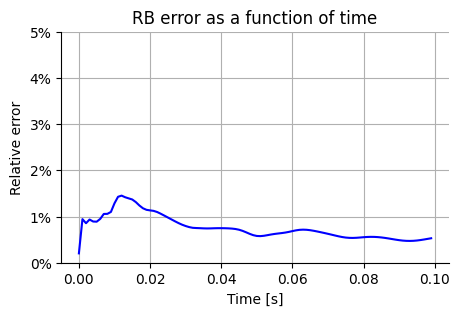

Result of the plot: I have one curve which is representing, for each time instant, the mean of the tests taken into account (15 tests)


In [33]:
# Let us define the RB error along time
T = dt * steps                                                      # It is the period for the computation of the system (T = dt * steps)
error_over_time = error_each_test.mean(axis = 0)                    # I calculate it in order to have the mean of all the mean tests for each time interval. It is used for the plot
time = np.linspace(0, T, len(error_over_time))                      # Define the x-axis (just like in matlab); define between 0 and T and cut the resolution depending on the lenght of the errors

# Plot the RB error as a function of time
plt.figure(figsize = (5, 3))
plt.plot(time, error_over_time, 'b')                                # Plot of the error(t)

# Custom the labels
plt.xlabel("Time [s]")
plt.ylabel("Relative error")
plt.title("RB error as a function of time")
plt.yticks([0, 0.01, 0.02, 0.03, 0.04, 0.05], ["0%", "1%", "2%" ,"3%", "4%", "5%"])
plt.grid(True)

# Remove the axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()


print("Result of the plot: I have one curve which is representing, for each time instant, the mean of the tests taken into account (15 tests)")

In [34]:
print(f"The length of time is {time.shape} i.e. steps + 1 since we have 99 steps + the initial value = 0; we start from 0. This is why we have +1")

The length of time is (100,) i.e. steps + 1 since we have 99 steps + the initial value = 0; we start from 0. This is why we have +1


In [35]:
print(f"{len(error_each_test)}")

15


### 3. Analysis of the spread of the errors along the 15 simulations in the test set

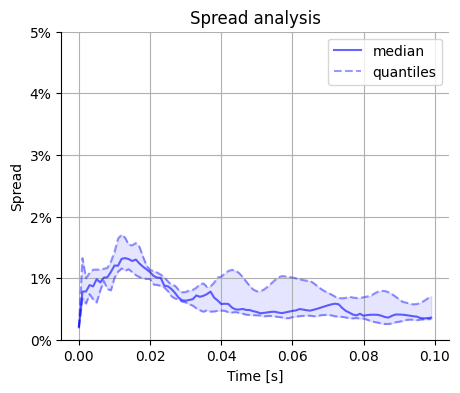

In [36]:
# Let us define the RB error along time
T = dt * steps                                       # It is the period for the computation of the system (T = dt * steps = 0.1 approximately)
error_each_testT = error_each_test.T
time2 = np.linspace(0, T, len(error_each_testT))      # Define the x-axis (just like in matlab); define between 0 and T and cut the resolution depending on the lenght of the errors

# Define the statistical tools for analyzing the spread
median = np.quantile(error_each_test, 0.5, axis = 0)         # Define the median
q1 = np.quantile(error_each_test, 0.25, axis = 0)            # Min range (box plot)
q3 = np.quantile(error_each_test, 0.75, axis = 0)            # Max range (box plot)
# Plot the spread of the error by using quantiles and median; median in insensitive to outliers and quantiles give a range of reference
plt.figure(figsize = (5, 4))
plt.plot(time2, median, '-b', label = 'median', alpha = 0.6)
plt.plot(time2, q1, '--b', label = 'quantiles', alpha = 0.4)
plt.plot(time2, q3, '--b', alpha = 0.4)
plt.fill_between(time2, q1, q3, color = 'blue', alpha = 0.1)

# # Custom the labels
plt.xlabel("Time [s]")
plt.ylabel("Spread")
plt.title("Spread analysis")
plt.yticks([0, 0.01, 0.02, 0.03, 0.04, 0.05], ["0%", "1%", "2%" ,"3%", "4%", "5%"])
plt.legend()
plt.grid(True)

# Remove the axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

In [37]:
median.shape, q1.shape, q3.shape, errors.shape, time2.shape

((100,), (100,), (100,), (100,), (100,))

In [38]:
time2.shape

(100,)

## Determination of the value of $E$ when $P>50$%

3 steps are performed:
1. In order to perform this step, I simply developed a "for cycle" in which in each step we have that $E$ is increasing with a certain step. The size of the step on E is determined by the linspace. In each cycle, we perform an RBsolver associated to the value of $E$ in analysis and then determine the probability for that solution that we determine. Consequently, we append the results on an array.
2. As we reach a probability higher that $0.5$, then we start append to another array. From this array, we only get the first value, that will be the very first value of $E$ for which we have $P>0.5$.
3. The arrays P_total and Es_total are applied for the plot in order to show the behavior of the system.

In [39]:
## Probability of having the electron in top region of the plate
if not data_loaded:
  # E = ? such that P >= 0.5? As deltaV0 = 100
  deltaV0_fixed = 100                           # Given
  E_values = np.linspace(0, 1000, 1000)         # Range of E given => change the value here in order to obtain a different step

  # Define probability array (P(Es, deltaV0=100))
  P_results = np.array([[]])

  # Define Es values to be analyzed for the "E" value such that P > 50%
  Es = np.array([[]])

  # Define P and E arrays for the plot of the entire probability behavior in function of E (P(E))
  P_total = np.array([[]])
  Es_total = np.array([[]])

  # Look for each "E"
  for E in E_values:
      mu_3 = [E, deltaV0_fixed]                              # Define mu
      psi_reduced_evolution = RBsolver(mu_3)                 # Apply the RB solver realized before associated to the value of E and deltaV0 (deltaV0 is fixed, while E is tested and changes for each "for" cycle)
      probability = probabilities(psi_reduced_evolution)     # probability in function of the values obtained by considering the mu_3 values
      P = caught(probability)
      P_total = np.append(P_total, P)
      Es_total = np.append(Es_total, E)
      if P >= 0.5:
          P_results = np.append(P_results, P)
          Es = np.append(Es, E)

  # To memorize the values which will be used for the plots
  Es_exceed = Es[0]
  P_exceed = P_results[0]

  print(f" When the probability is of {100*P_exceed:.3f} %, that is the minimum probability for which we have a value of E such that we exceed P = 50%, we expect to have E = {Es_exceed:.3f}" )
else:
    print("Using pre-loaded Es_exceed, P_exceed, P_total, Es_total, P_results from file.")
    Es_exceed = data['Es_exceed']
    P_exceed = data['P_exceed']
    P_total = data['P_total']
    Es_total = data['Es_total']
    P_results = data['P_results']

# Es_fifty = Es[0]
print(f" When the probability is of {100*P_exceed:.3f} %, that is the minimum probability for which we have a value of E such that we exceed P = 50%, we expect to have E = {Es_exceed:.3f}" )


Using pre-loaded Es_exceed, P_exceed, P_total, Es_total, P_results from file.
 When the probability is of 50.045 %, that is the minimum probability for which we have a value of E such that we exceed P = 50%, we expect to have E = 621.622


In [40]:
# E = ? such that P >= 0.5? As deltaV0 = 100
deltaV0_fixed = 100                           # Given
E_values = np.linspace(0, 1000, 1000)         # Range of E given => change the value here in order to obtain a different step

# Define probability array (P(Es, deltaV0=100))
P_results = np.array([[]])

# Define Es values to be analyzed for the "E" value such that P > 50%
Es = np.array([[]])

# Define P and E arrays for the plot of the entire probability behavior in function of E (P(E))
P_total = np.array([[]])
Es_total = np.array([[]])

# Look for each "E"
for E in E_values:
    mu_3 = [E, deltaV0_fixed]                              # Define mu
    psi_reduced_evolution = RBsolver(mu_3)                 # Apply the RB solver realized before associated to the value of E and deltaV0 (deltaV0 is fixed, while E is tested and changes for each "for" cycle)
    probability = probabilities(psi_reduced_evolution)     # probability in function of the values obtained by considering the mu_3 values
    P = caught(probability)
    P_total = np.append(P_total, P)
    Es_total = np.append(Es_total, E)
    if P >= 0.5:
        P_results = np.append(P_results, P)
        Es = np.append(Es, E)

# To memorize the values which will be used for the plots
Es_exceed = Es[0]
P_exceed = P_results[0]

print(f" When the probability is of {100*P_exceed:.3f} %, that is the minimum probability for which we have a value of E such that we exceed P = 50%, we expect to have E = {Es_exceed:.3f}" )


 When the probability is of 50.045 %, that is the minimum probability for which we have a value of E such that we exceed P = 50%, we expect to have E = 621.622


In [41]:
Es_exceed.shape, P_exceed.shape, P_total.shape, Es_total.shape

((), (), (1000,), (1000,))

### How probability varies with the electric field: Plot

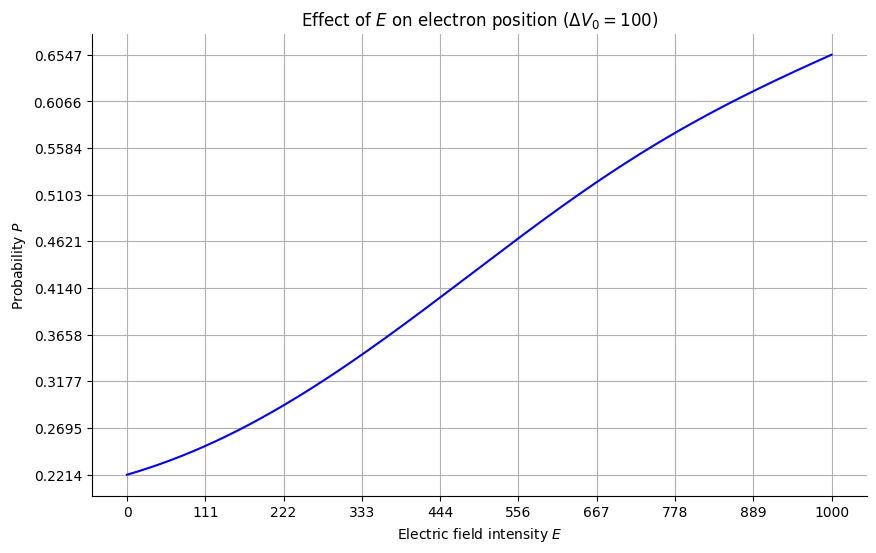

Increasing E pushes the electron toward the upper crystal plate, increasing the probability P. The transition threshold is observed around E≈624.


In [42]:
# Do the plot
plt.figure(figsize=(10, 6))
plt.plot(Es_total, P_total, 'b-')
# plt.axhline(y=0.5, color='r', linestyle='--', label='50% threshold')
plt.xlabel('Electric field intensity $E$')
plt.ylabel('Probability $P$')
plt.title("Effect of $E$ on electron position ($\\Delta V_0 = 100$)")
plt.grid(True)

# Consider more thicks
plt.xticks(np.linspace(min(Es_total), max(Es_total), 10))
plt.yticks(np.linspace(min(P_total), max(P_total), 10))

# Remove the axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

print("Increasing E pushes the electron toward the upper crystal plate, increasing the probability P. The transition threshold is observed around E≈624.")

## Comparison between the Full Order Model and the Reduced Order Model

In this part, altough it was not requested, I decided to add some plots in order to better analyze the behavior of the systems. The reason behind the plots that I decided to put is that I wanted to understand whether the results were reliable and to check whether the RBsolver worked successfully.
The plots defined are:
1. Comparison of the animations
2. Analysis of the error at timesteps > 99.
3. Error analysis when a parameter is out of the training region.
4. Compare different time instants between FOM and ROM.
5. Varying the value of dt.

We can see that in each block we are applying the RBsolver and the time required is quite low

### 1. Comparing the animations

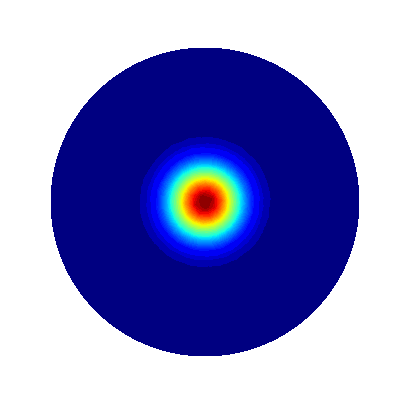

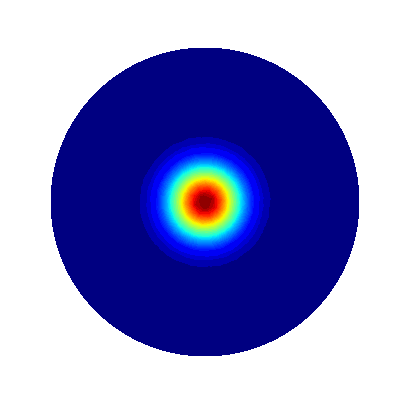

(None, None)

In [43]:
# ROM solution
E_test = 800
deltaV0_test = 50
mutest = np.array([E_test, deltaV0_test])
uRB = RBsolver(mutest, dt, steps)

# FOM solution
u_anim = FOMsolver(800, 50)

# Animation of both solutions (comparison)
fe.animate(probabilities(u_anim), Vh), fe.animate(probabilities(uRB), Vh)

### 2. Analysis of the error at timesteps > 99

Use timestep

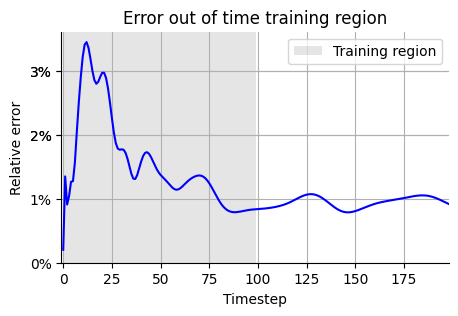

In [44]:
# We decide to apply the FOM and RB solver for a time instant which is twice the time steps that we considered (i.e. steps = 198)
steps_exceed = steps * 2
E_exceed = 1000 * np.random.rand()           # (0, infinity) - 1000 approximately equal to infinity
deltaV0_exceed = 1000 * np.random.rand()     # (0, 1000)
mu2 = np.array([E_exceed, deltaV0_exceed])
uRB_exceed = RBsolver(mu2, steps=steps_exceed)
uFOM_exceed = FOMsolver(mu2[0], mu2[1], steps_exceed)

# Formula
error_over_steps = np.linalg.norm(uFOM_exceed-uRB_exceed, axis = 1)/np.linalg.norm(uFOM_exceed, axis = 1)

# Plot
plt.figure(figsize = (5, 3))
plt.plot(error_over_steps, 'b')

# Define text
plt.xlabel("Timestep")
plt.ylabel("Relative error")
plt.title("Error out of time training region")

# Define region
marks = np.linspace(error_over_steps.min(), error_over_steps.max(), 6)
marks = [round(mark, 2) for mark in marks]
plt.yticks(marks, [num2p(mark).replace(".00", "") for mark in marks])
ylim = plt.gca().get_ylim()
plt.fill([0, steps, steps, 0], [ylim[0], ylim[0], ylim[1], ylim[1]], 'k', label = "Training region", alpha = 0.1)
plt.axis([-1, steps_exceed, *ylim])
# Custom the plot
plt.grid(True)
plt.legend()

# Remove the axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

Use vector time as x axis

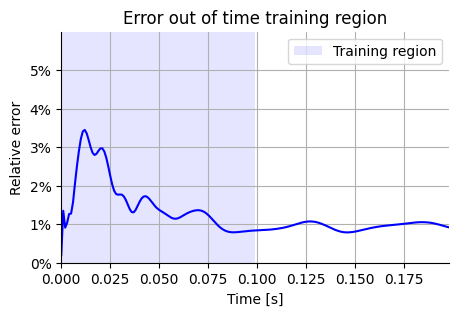

In [45]:
# We decide to apply the FOM and RB solver for a time instant which is twice the time steps that we considered (i.e. steps2 = 198)

# Define time vector
time_exceed = np.linspace(0, steps_exceed * dt, steps_exceed + 1)

# Plot
plt.figure(figsize = (5, 3))
plt.plot(time_exceed, error_over_steps, 'b')

# Custom titles
plt.xlabel("Time [s]")
plt.ylabel("Relative error")
plt.title("Error out of time training region")
plt.yticks([0, 0.01, 0.02, 0.03, 0.04, 0.05], ["0%", "1%", "2%" ,"3%", "4%", "5%"])

# Define limits of the axes
ylim = [0, 0.06]
plt.axis([0, steps_exceed * dt, *ylim])
plt.fill([0, dt*steps, dt*steps, 0], [ylim[0], ylim[0], ylim[1], ylim[1]], 'b', label = "Training region", alpha = 0.1)

# Custom the plot
plt.grid(True)
plt.legend()

# Remove the axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

In [46]:
uRB_exceed.shape, uFOM_exceed.shape

((199, 1990), (199, 1990))

### 3. Error when "ΔV > 1000"

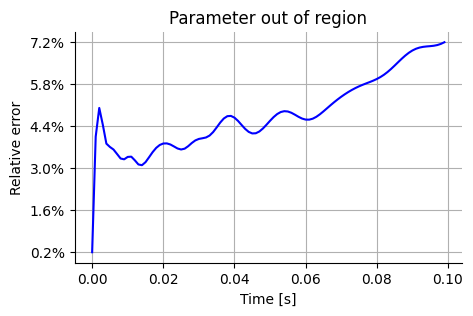

In [47]:
E_out= 1000 * np.random.rand()
deltaV0_out = 2000
mu_out = np.array([E_out, deltaV0_out])
uFOM_out = FOMsolver(mu_out[0], mu_out[1], steps = 99)
uRB_out = RBsolver(mu_out, steps = 99)

error_parameter_change = np.linalg.norm(uFOM_out-uRB_out, axis = 1)/np.linalg.norm(uFOM_out, axis = 1)
plt.figure(figsize = (5, 3))
plt.plot(time, error_parameter_change, 'b')

# Custom the labels
plt.xlabel("Time [s]")
plt.ylabel("Relative error")
plt.title("Parameter out of region")
marks = np.linspace(error_parameter_change.min(), error_parameter_change.max(), 6)
plt.yticks(marks, [f"{mark:.1%}" for mark in marks])
plt.grid(True)


# Remove the axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

### 4. Compare different time instants between FOM and ROM

The plots, by using the same parameter for both FOM and ROM for every chosen time instant, are pretty much the same, proving that the solution obtained with the reduced basis is reliable.


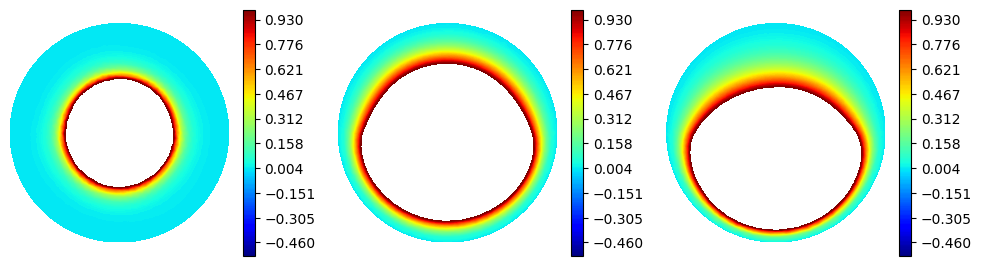

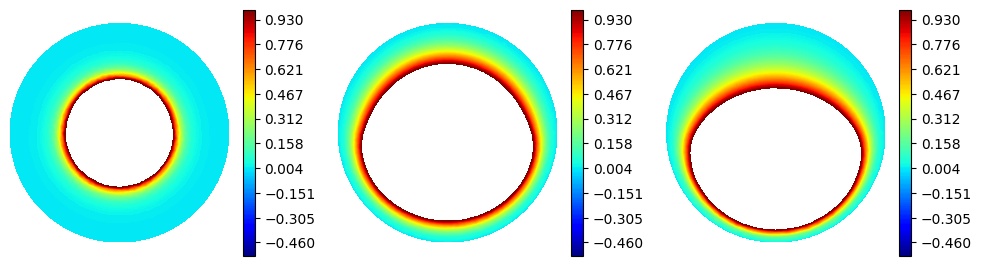

In [48]:
# Define the mu parameter
mu_plots_t_instants = [2, 100]

# Define the RB solution
uRBplots_t_instants = RBsolver(mu_plots_t_instants, dt, steps)
uRBplots_t_instants = fe.multiplot(probabilities(uRBplots_t_instants[[1, 50, 90]]), (1, 3), Vh, colorbar = True, vmin = u.min(), vmax = u.max())

# Define the FOM solution
uFOMplots_t_instants  = FOMsolver(mu_plots_t_instants[0], mu_plots_t_instants[1])
uFOMplots_t_instants  = fe.multiplot(probabilities(uFOMplots_t_instants[[1, 50, 90]]), (1, 3), Vh, colorbar = True, vmin = u.min(), vmax = u.max())

print("The plots, by using the same parameter for both FOM and ROM for every chosen time instant, are pretty much the same, proving that the solution obtained with the reduced basis is reliable.")


### 5. Varying dt

### dt > 1e-3

In [49]:
dt2 = 1e-3 * 2
Edt = 1000* np.random.rand()                        # (0, infinity) - 1000 approximately equal infinity here
deltaV0dt = 1000 * np.random.rand()                 # (0, 1000)
mudt = np.array([Edt, deltaV0dt])                   # Select random values for tests for mu0

# For the error analysis, we need 2 solutions of same dimension
uRBdt = RBsolver(mudt, dt2, steps)
uFOMdt = FOMsolver(mudt[0], mudt[1], steps = steps, dt = dt2)
uRBdt.shape, uFOMdt.shape

((100, 1990), (100, 1990))

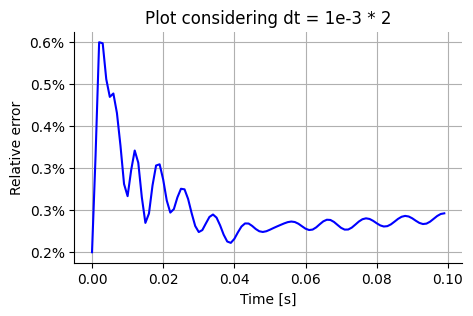

In [50]:
# Let us define the RB error along time
error_dt = np.linalg.norm(uFOMdt-uRBdt, axis = -1)/np.linalg.norm(uFOMdt, axis = -1)

# Plot the RB error as a function of time
plt.figure(figsize = (5, 3))
plt.plot(time, error_dt, 'b')                                # Plot of the error(t)

# Custom the labels
plt.xlabel("Time [s]")
plt.ylabel("Relative error")
plt.title("Plot considering dt = 1e-3 * 2")
marks = np.linspace(error_dt.min(), error_dt.max(), 6)
plt.yticks(marks, [f"{mark:.1%}" for mark in marks])
plt.grid(True)

# Remove the axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()


### dt < 1e-3

In [51]:
dt3 = 1e-3 / 2
Edt2 = 1000* np.random.rand()                        # (0, infinity) - 1000 approximately equal infinity here
deltaV0dt2 = 1000 * np.random.rand()                 # (0, 1000)
mudt2 = np.array([Edt2, deltaV0dt2])                   # Select random values for tests for mu0

# For the error analysis, we need 2 solutions of same dimension
uRBdt2 = RBsolver(mudt2, dt3, steps)
uFOMdt2 = FOMsolver(mudt2[0], mudt2[1], steps = 99 , dt = dt3)
uRBdt2.shape, uFOMdt2.shape

((100, 1990), (100, 1990))

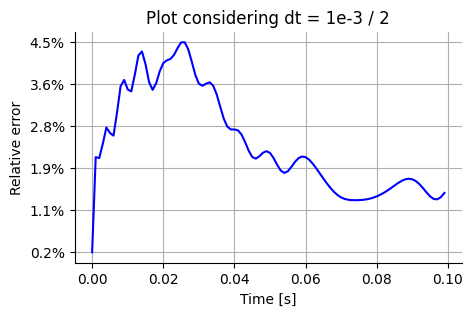

In [52]:
# Let us define the RB error along time
error_dt2 = np.linalg.norm(uFOMdt2-uRBdt2, axis = -1)/np.linalg.norm(uFOMdt2, axis = -1)

# Plot the RB error as a function of time
plt.figure(figsize = (5, 3))
plt.plot(time, error_dt2, 'b')                                # Plot of the error(t)

# Custom the labels
plt.xlabel("Time [s]")
plt.ylabel("Relative error")
plt.title("Plot considering dt = 1e-3 / 2")
marks = np.linspace(error_dt2.min(), error_dt2.max(), 6)
plt.yticks(marks, [f"{mark:.1%}" for mark in marks])
plt.grid(True)

# Remove the axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()